In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [46]:
def prepare_transition_set_ofret(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2.5,
    wavelength=640,
    bleaching=False,
    energy_transfer=True,
    dstorm=True,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [1, 0.0001]}, 
                                'exclude': ['s0']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set


### Excitation rate calculation
2.5 kW/cm² was measured as the experimental irradiance. It is very likely that this was the average for 1 s. The laser pulses have a frequency of 80MHz, meaning within 1 s, there were 8e7 pulses, each with a duration of 50 ps (5e-11s). This means that during 1 s,  5e-11*8e7s = 4e-3s of irradiation happened. This means that the irradiance of a single pulse must have been 1/4e-3 times higher than the average. 

### 4F 3nm dSTORM

In [58]:
filepath = r"c:\Users\vie43sq\Desktop\Simulations\simulation_data\OET_lifetimes\4f_3nm_dstorm"
lifetimes_file = fr"{filepath}\lifetimes.npy"
event_time_series_file = fr"{filepath}\event_time_series.parquet"

transition_set = prepare_transition_set_ofret(4, 3)
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all = \
    emis.tcspc(transition_set, number_pulses=1e8, excitation_rates={'cy5_dna': 3.75e9},
               time_between_pulses=12.5e-9)

emis.event_time_series.to_frame().to_parquet(event_time_series_file)
np.save(lifetimes_file, lifetimes_all)

WARNING for line:     warnings.warn(
 the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames. 


In [63]:
# filtering
photon_collection_rate = fo.calculate_photon_collection_rate(
    NA=1.45, n1=1.51
)
emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
emis.add_transmittance(p=0.99, seed=rng) # lens 1
emis.add_transmittance(p=0.99, seed=rng) # lens 2
emis.add_quantum_efficiency(p=0.85, seed=rng)
emis.add_poisson_noise(rate=0.6, seed=rng)
emis.apply_threshold(threshold=10)

array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

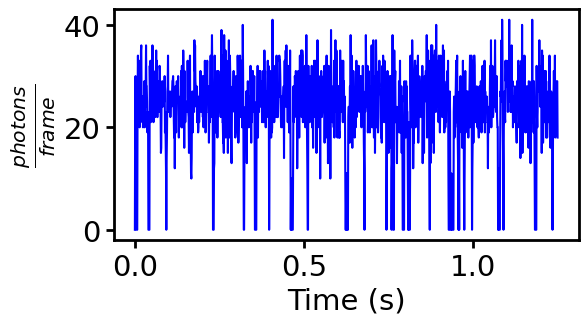

In [64]:
emis.plot_time_series()

In [ ]:
g = pd.read_parquet(event_time_series_file)
g = pd.Series(g.values.flatten(), index=g.index)
lifetimes_all = np.load(lifetimes_file)

array([3.52182713e-12, 1.45751434e-09, 1.52170539e-09, 8.07108142e-10,
       1.56363300e-09, 2.52113588e-09, 3.36394184e-09, 5.92952193e-10,
       8.15081013e-10, 1.56737557e-09, 1.34551399e-09, 4.85969431e-09,
       6.53161088e-10, 7.29864625e-10, 1.13961422e-09, 1.34821282e-09,
       1.35879774e-09, 2.21788726e-09, 3.33430170e-09, 1.28288982e-09,
       2.20209007e-09, 4.41190885e-10, 1.40791294e-09, 1.28170203e-08,
       3.64731225e-09, 1.49827932e-09, 8.54278516e-11, 5.94485347e-09,
       1.22104210e-09, 3.18911116e-11, 2.31466942e-09, 4.77717418e-10,
       1.10277396e-09, 2.16314764e-09, 5.97746615e-10, 5.58085495e-10,
       8.89252476e-11, 4.81519237e-10, 3.94768498e-10, 2.40471205e-09,
       3.41724496e-10, 5.58371279e-09, 3.67055449e-11, 2.72719199e-10,
       6.72462768e-10, 9.48336507e-10, 6.37794438e-11, 3.75613384e-11,
       2.23592111e-09, 3.96386608e-09, 1.10968631e-09, 2.75194349e-09,
       2.96020949e-11, 5.20234021e-09, 2.59176539e-09, 2.28600628e-09,
      

### 4F 18nm dSTORM

In [56]:
filepath = r"c:\Users\vie43sq\Desktop\Simulations\simulation_data\OET_lifetimes\4f_18nm_dstorm"
lifetimes_file = fr"{filepath}\lifetimes.npy"
event_time_series_file = fr"{filepath}\event_time_series.parquet"

transition_set_18 = prepare_transition_set_ofret(4, 18)
rng = np.random.default_rng(42)
emis_18 = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da_18, D_18, lifetimes_all_18 = \
    emis_18.tcspc(transition_set_18, number_pulses=1e8, excitation_rates={'cy5_dna': 3.75e9},
               time_between_pulses=12.5e-9)

emis_18.event_time_series.to_frame().to_parquet(event_time_series_file)
np.save(lifetimes_file, lifetimes_all_18)

WARNING for line:     warnings.warn(
 the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames. 


array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

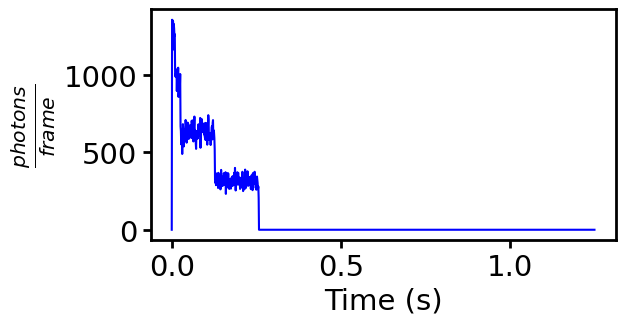

In [57]:
emis_18.plot_time_series()

In [20]:
transition_set = prepare_transition_set_ofret(4, 9)
rng = np.random.default_rng(42)
emis_9 = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
DA_9, D_9, lifetimes_all_9 = emis_9.tcspc(transition_set, number_pulses=3e7, excitation_rates={'cy5_dna': 1.5e10})

WARNING for line:     warnings.warn(
 the last frame (of index 3.0) has 0.00e+00 times the pulses of other frames. 


array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

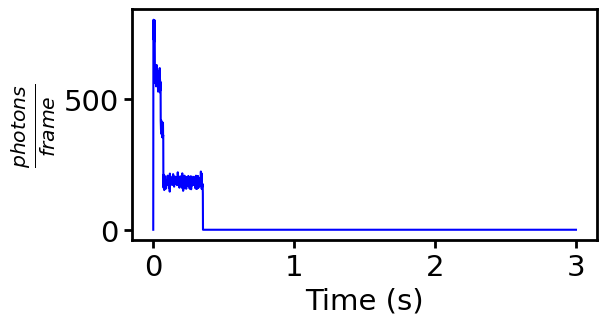

In [21]:
emis_9.plot_time_series()

In [24]:
blinks_9 = bl.Blinking(emis_9, threshold=20)

In [25]:
blinks_9.off_periods

array([], dtype=int64)

In [36]:
DA.mean()

6.72575006826046e-10

In [38]:
DA.size/D.size

0.23200900884861217

In [37]:
lifetimes_all.mean()

1.5036185411580305e-09

array([[<Axes: title={'center': 'lifetimes'}, xlabel='time (s)', ylabel='PD'>]],
      dtype=object)

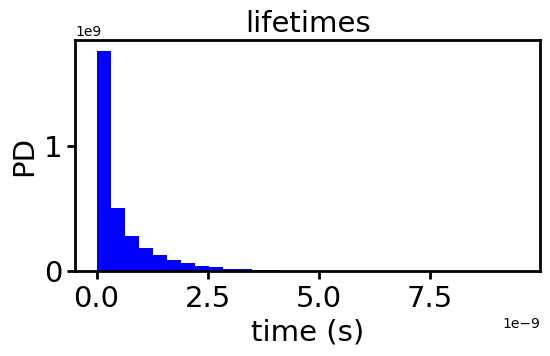

In [29]:
fi.universal_figure(data=DA, type_='hist', density=True, 
                    title='lifetimes', 
                    ylabel='PD', xlabel='time (s)', 
                     bins=30) 

In [18]:
transition_set.transition_df

transition_type  \
Fluorophore                         identity                                           
cy5_dna                             0                      TransitionType.EXCITATION   
                                    1            TransitionType.FLUORESCENT_EMISSION   
                                    2         TransitionType.INTERSYSTEM_CROSSING_ST   
                                    3                   TransitionType.ISOMERIZATION   
                                    4                      TransitionType.THERM_BISO   
                                    5                     TransitionType.REDUCTION_T   
                                    6                     TransitionType.REDUCTION_S   
                                    7                     TransitionType.OXIDATION_1   
                                    8               TransitionType.S1_S0_TRANSITIONS   
                                    9               TransitionType.T1_S0_TRANSITIONS   
                                    10             TransitionType.CIS_S0_TRANSITIONS   
D: cy5_dna, A: cy5_dna, dist: 3.0   11                     TransitionType.CIS_FRET_1   
                                    12                     TransitionType.CIS_FRET_2   
                                    13                     TransitionType.OFF_FRET_1   
                                    14                     TransitionType.OFF_FRET_2   
                                    15               TransitionType.S_S_ANNIHILATION   
                                    16             TransitionType.S_T_ANNIHILATION_1   
D: cy5_dna, A: cy5_dna, dist: 4.243 17                     TransitionType.CIS_FRET_1   
                                    18                     TransitionType.CIS_FRET_2   
                                    19                     TransitionType.OFF_FRET_1   
                                    20                     TransitionType.OFF_FRET_2   
                                    21               TransitionType.S_S_ANNIHILATION   
                                    22             TransitionType.S_T_ANNIHILATION_1   

                                             abbreviation  \
Fluorophore                         identity                
cy5_dna                             0                 EXC   
                                    1                 FLU   
                                    2               ISCST   
                                    3                 ISO   
                                    4               TBISO   
                                    5                REDT   
                                    6                REDS   
                                    7                OXI1   
                                    8             S1S0SUM   
                                    9             T1S0SUM   
                                    10           CisS0SUM   
D: cy5_dna, A: cy5_dna, dist: 3.0   11             CFRET1   
                                    12             CFRET2   
                                    13             OFRET1   
                                    14             OFRET2   
                                    15                SSA   
                                    16               STA1   
D: cy5_dna, A: cy5_dna, dist: 4.243 17             CFRET1   
                                    18             CFRET2   
                                    19             OFRET1   
                                    20             OFRET2   
                                    21                SSA   
                                    22               STA1   

                                                    initial_state  \
Fluorophore                         identity                        
cy5_dna                             0              SingleState.S0   
                                    1              SingleState.S1   
                                    2              SingleState.S1 

In [11]:
distances = [3, 6, 9, 18]
rng = np.random.default_rng(42)
lifetimes_all_distances = []
for distance in distances:
    transition_set = prepare_transition_set_ofret(4, distance)
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    _, _, lifetimes_all = emis.tcspc(transition_set, number_pulses=2e6, excitation_rates={'cy5_dna': 1.5e10})
    lifetimes_all_distances.append(lifetimes_all)

WARNING for line:     warnings.warn(
 the last frame (of index 0.199) has 1.00e+00 times the pulses of other frames. 
WARNING for line:     warnings.warn(
 the last frame (of index 0.199) has 1.00e+00 times the pulses of other frames. 
WARNING for line:     warnings.warn(
 the last frame (of index 0.199) has 1.00e+00 times the pulses of other frames. 
WARNING for line:     warnings.warn(
 the last frame (of index 0.199) has 1.00e+00 times the pulses of other frames. 


1.6431152602667397e-09
1.5839440111851311e-09
1.635775190633464e-09
1.6711895573268461e-09


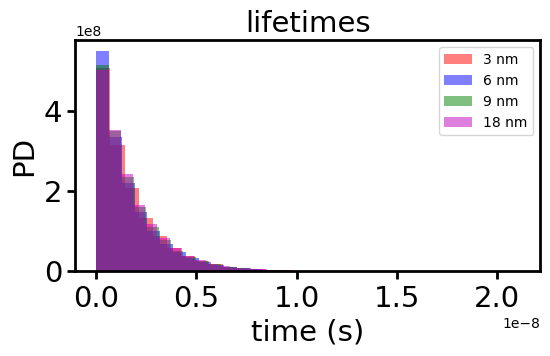

In [15]:
axes = fi.universal_figure()
colors = ['r', 'b', 'g', 'm']
for i, (lifetimes, distance) in enumerate(zip(lifetimes_all_distances, distances)):
    print(np.mean(lifetimes))
    fi.universal_figure(data=lifetimes, type_='hist', density=True, 
                        axes=axes[0, 0], title='lifetimes', 
                        ylabel='PD', xlabel='time (s)', label=f'{distance} nm',
                        legend=True, color=colors[i], bins=30, alpha=0.5)   